# 99 · Publication-quality figures

Consolidates the main paper figures with consistent styling: colour-blind palette, panel letters, clear units, statistical annotations, 300 dpi PNG + TIFF.

**Figure 1.** Mean trajectories + predicted LMM trajectories (2 panels).
**Figure 2.** Waterfall + violin of Δpain (2 panels).
**Figure 3.** Mediation decomposition (forest plot).
**Figure 4.** Non-motor symptom network (GLASSO) highlighting pain.
**Figure 5.** Kaplan-Meier at two thresholds (2 panels).
**Figure 6.** Prediction model — ROC + feature importance (2 panels).
**Figure 7.** Forest of main effect sizes across analyses.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(patchwork)
  library(scales); library(ggtext); library(forcats); library(glasso); library(qgraph)
  library(survival); library(survminer); library(pROC)
})

# Global theme
theme_pub <- function(base_size = 11) {
  theme_classic(base_size = base_size, base_family = "Helvetica") +
    theme(
      plot.title        = element_text(face = "bold", size = rel(1.05), hjust = 0),
      plot.subtitle     = element_text(size = rel(0.9), colour = "grey30", hjust = 0),
      plot.caption      = element_text(size = rel(0.8), colour = "grey40", hjust = 0),
      axis.title        = element_text(face = "plain", size = rel(0.95)),
      axis.text         = element_text(colour = "grey20"),
      legend.title      = element_text(face = "plain"),
      legend.position   = "top",
      legend.key.height = grid::unit(0.6, "lines"),
      strip.background  = element_blank(),
      strip.text        = element_text(face = "bold", size = rel(0.95)),
      panel.grid.major.y = element_line(colour = "grey90", linewidth = 0.25)
    )
}
TRAJ_PAL <- c(`Pre-DBS` = "#117733", `Post-DBS` = "#CC6677", `Never-DBS` = "#332288")
ARM_PAL  <- c(`DBS` = "#CC6677", `Never-DBS` = "#332288")

save_pub <- function(p, name, w = 7.2, h = 5, panel_letter = NULL) {
  if (!is.null(panel_letter)) p <- p + labs(tag = panel_letter) + theme(plot.tag = element_text(face = "bold", size = 14))
  ggplot2::ggsave(file.path(OUT_FIG, paste0(name, ".png")),  plot = p, width = w, height = h, dpi = 300)
  ggplot2::ggsave(file.path(OUT_FIG, paste0(name, ".tiff")), plot = p, width = w, height = h, dpi = 300, compression = "lzw")
  invisible(p)
}

Warning message:
“package ‘survminer’ was built under R version 4.5.2”


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 6206' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 6206' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



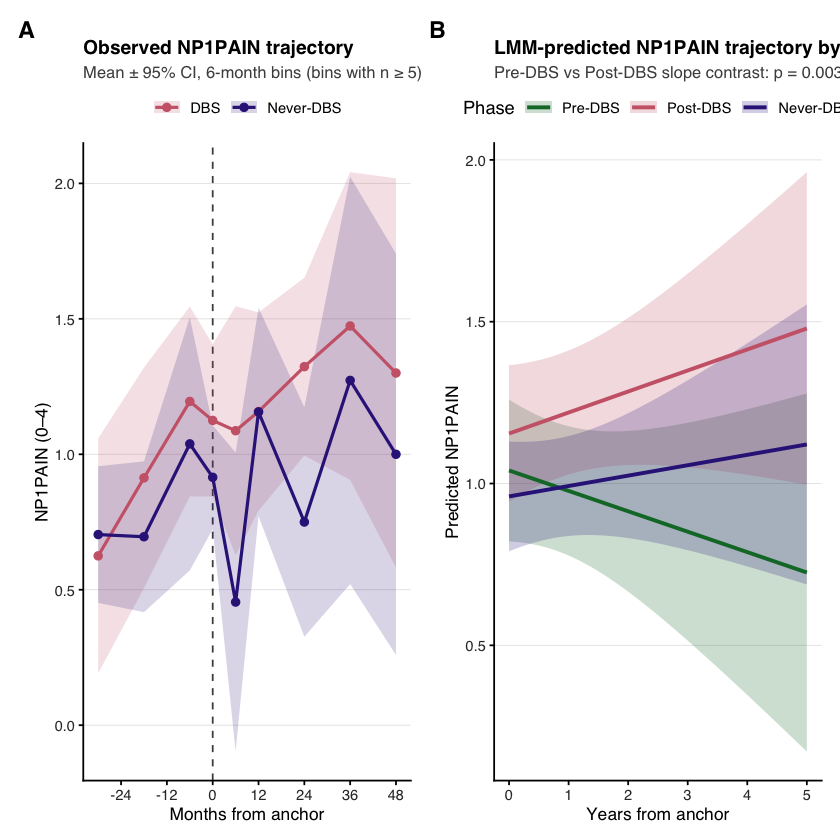

In [2]:
# ========= Figure 1 — Trajectories (panel A: raw mean ± 95% CI, panel B: LMM predicted) =========
df_long <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
suppressPackageStartupMessages({ library(lme4); library(emmeans) })

ded <- dedup_earliest_per_bin(df_long)
raw <- ded %>% dplyr::filter(!is.na(NP1PAIN)) %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS")) %>%
  dplyr::group_by(months, arm) %>%
  dplyr::summarise(m = mean(NP1PAIN), se = stats::sd(NP1PAIN)/sqrt(dplyr::n()),
                   n = dplyr::n(), .groups = "drop") %>%
  dplyr::filter(n >= 5, months >= -36, months <= 48) %>%
  dplyr::mutate(lo = m - 1.96 * se, hi = m + 1.96 * se)

pA <- ggplot(raw, aes(months, m, colour = arm, fill = arm)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey30") +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.18, colour = NA) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  scale_fill_manual(values = ARM_PAL, name = NULL) +
  scale_x_continuous(breaks = seq(-36, 48, 12)) +
  labs(title = "Observed NP1PAIN trajectory", subtitle = "Mean ± 95% CI, 6-month bins (bins with n ≥ 5)",
       x = "Months from anchor", y = "NP1PAIN (0–4)", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

# Panel B — LMM predicted
dbs_ids <- df_long %>% dplyr::filter(traj == "Post-DBS") %>% dplyr::pull(PATNO) %>% unique()
excl <- df_long %>% dplyr::filter(traj == "Pre-DBS", PATNO %in% dbs_ids) %>%
  dplyr::group_by(PATNO) %>%
  dplyr::summarise(mx = max(time_pos_months, na.rm = TRUE), .groups = "drop") %>%
  dplyr::filter(mx > 60) %>% dplyr::pull(PATNO)
lmm_data <- df_long %>% dplyr::filter(!PATNO %in% excl) %>%
  dplyr::mutate(time = time_pos_months / 12)   # years
m <- lme4::lmer(NP1PAIN ~ time * traj + (1 + time | PATNO), data = lmm_data,
                weights = weight_sw_trim90, REML = FALSE,
                control = lme4::lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))
grid <- expand.grid(time = seq(0, 5, length.out = 200),
                    traj = factor(c("Pre-DBS","Post-DBS","Never-DBS"),
                                  levels = c("Pre-DBS","Post-DBS","Never-DBS")))
pr <- predict(m, newdata = grid, re.form = NA, se.fit = TRUE)
pred <- dplyr::bind_cols(grid, tibble::tibble(fit = pr$fit,
                                              lci = pr$fit - 1.96*pr$se.fit,
                                              uci = pr$fit + 1.96*pr$se.fit))
sl <- emmeans::emtrends(m, specs = "traj", var = "time")
ct <- as.data.frame(pairs(sl, adjust = "tukey"))
p_prepost <- signif(ct %>% dplyr::filter(grepl("Pre-DBS", contrast), grepl("Post-DBS", contrast)) %>% dplyr::pull(p.value), 3)

pB <- ggplot(pred, aes(time, fit, colour = traj, fill = traj)) +
  geom_ribbon(aes(ymin = lci, ymax = uci), alpha = 0.22, colour = NA) +
  geom_line(linewidth = 1.1) +
  scale_colour_manual(values = TRAJ_PAL, name = "Phase") +
  scale_fill_manual(values = TRAJ_PAL, name = "Phase") +
  labs(title = "LMM-predicted NP1PAIN trajectory by phase",
       subtitle = sprintf("Pre-DBS vs Post-DBS slope contrast: p = %s", p_prepost),
       x = "Years from anchor", y = "Predicted NP1PAIN", tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

fig1 <- pA + pB + patchwork::plot_layout(ncol = 2)
fig1
save_pub(fig1, "Figure1_trajectories", w = 11, h = 4.4)

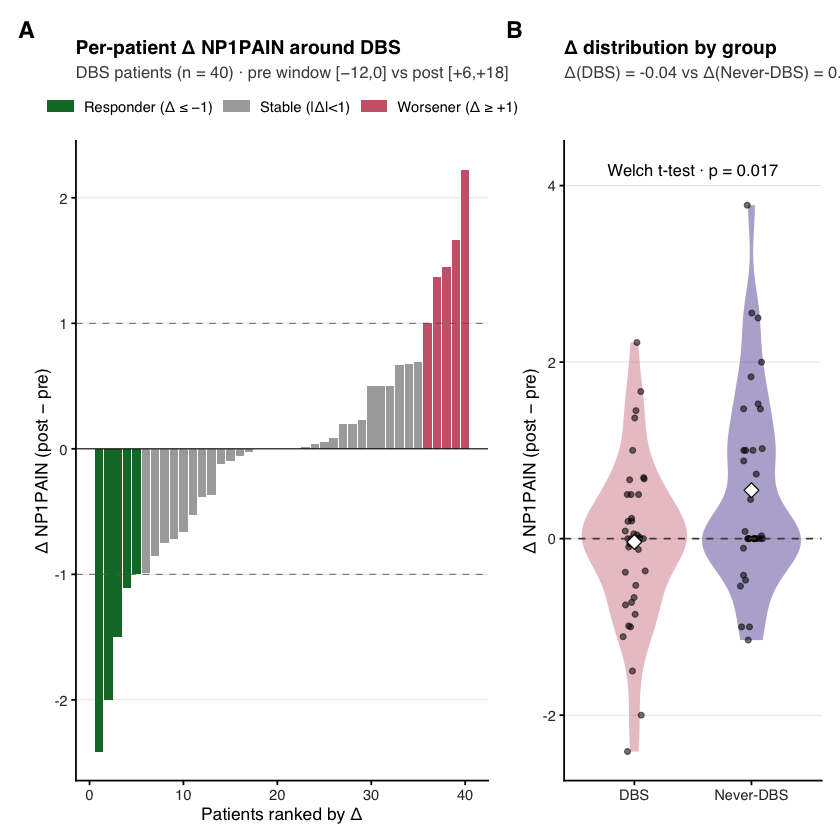

In [3]:
# ========= Figure 2 — Waterfall + violin =========
delta <- readRDS(file.path(OUT_OBJ, "pain_delta_responder.rds")) %>%
  dplyr::mutate(group = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))

wf_dbs <- delta %>% dplyr::filter(will_receive_dbs) %>%
  dplyr::arrange(delta) %>% dplyr::mutate(rank = dplyr::row_number(),
                                          status = dplyr::case_when(delta <= -1 ~ "Responder (Δ ≤ −1)",
                                                                     delta >= 1 ~ "Worsener (Δ ≥ +1)",
                                                                     TRUE ~ "Stable (|Δ|<1)"))
cols_status <- c("Responder (Δ ≤ −1)" = "#117733", "Stable (|Δ|<1)" = "#AAAAAA", "Worsener (Δ ≥ +1)" = "#CC6677")

pA <- ggplot(wf_dbs, aes(rank, delta, fill = status)) +
  geom_col(width = 0.9) +
  geom_hline(yintercept = 0, linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", colour = "grey40", linewidth = 0.25) +
  scale_fill_manual(values = cols_status, name = NULL) +
  labs(title = "Per-patient Δ NP1PAIN around DBS",
       subtitle = sprintf("DBS patients (n = %d) · pre window [−12,0] vs post [+6,+18]", nrow(wf_dbs)),
       x = "Patients ranked by Δ", y = "Δ NP1PAIN (post − pre)", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

tt <- stats::t.test(delta ~ group, data = delta)
pB <- ggplot(delta, aes(group, delta, fill = group)) +
  geom_violin(alpha = 0.4, colour = NA) +
  geom_jitter(width = 0.1, alpha = 0.55, size = 1.3) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey30") +
  stat_summary(fun = mean, geom = "point", shape = 23, fill = "white", size = 3) +
  scale_fill_manual(values = ARM_PAL, guide = "none") +
  annotate("text", x = 1.5, y = max(delta$delta) + 0.4,
           label = sprintf("Welch t-test · p = %.3f", tt$p.value), size = 3.5) +
  labs(title = "Δ distribution by group",
       subtitle = sprintf("Δ(DBS) = %.2f vs Δ(Never-DBS) = %.2f",
                          mean(delta$delta[delta$group=="DBS"]),
                          mean(delta$delta[delta$group=="Never-DBS"])),
       x = NULL, y = "Δ NP1PAIN (post − pre)", tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

fig2 <- pA + pB + patchwork::plot_layout(ncol = 2, widths = c(1.6, 1))
fig2
save_pub(fig2, "Figure2_waterfall_violin", w = 12, h = 4.4)

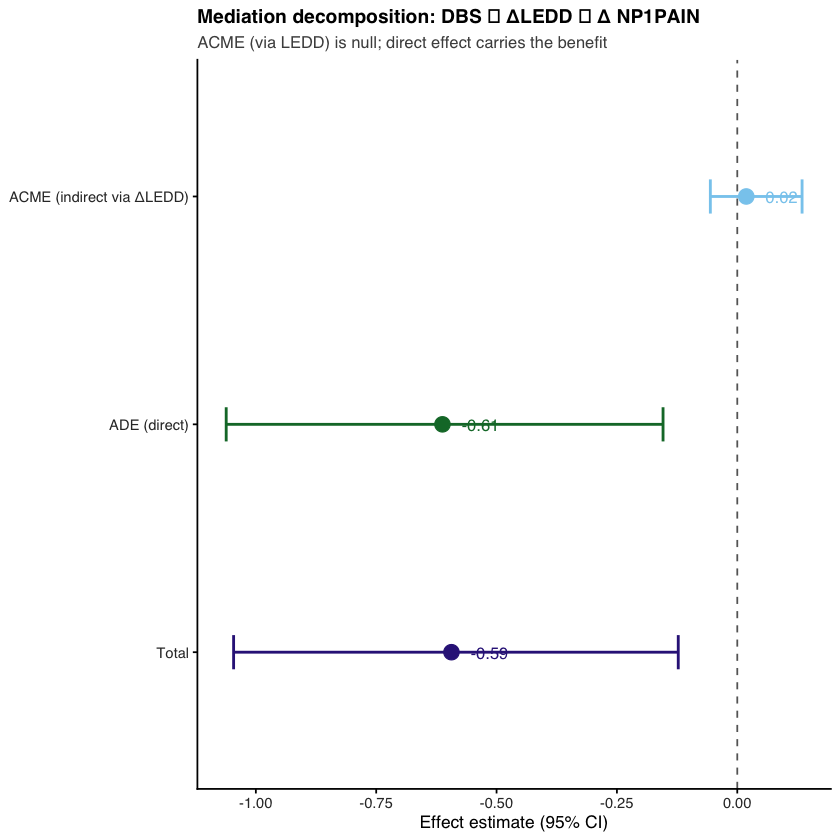

In [4]:
# ========= Figure 3 — Mediation decomposition =========
eff <- readr::read_csv(file.path(OUT_TAB, "mediation_effects.csv"), show_col_types = FALSE) %>%
  dplyr::filter(effect != "Prop. mediated") %>%
  dplyr::mutate(effect = forcats::fct_rev(forcats::fct_inorder(effect)))
pal_med <- c("Total" = "#332288", "ADE (direct)" = "#117733", "ACME (indirect via ΔLEDD)" = "#88CCEE")
fig3 <- ggplot(eff, aes(estimate, effect, colour = as.character(effect))) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = ci_lo, xmax = ci_hi), width = 0.15, orientation = "y", linewidth = 0.8) +
  geom_point(size = 4) +
  geom_text(aes(label = sprintf("%.2f", estimate), x = estimate + 0.04),
            size = 3.5, hjust = 0) +
  scale_colour_manual(values = pal_med, guide = "none") +
  labs(title = "Mediation decomposition: DBS → ΔLEDD → Δ NP1PAIN",
       subtitle = "ACME (via LEDD) is null; direct effect carries the benefit",
       x = "Effect estimate (95% CI)", y = NULL) +
  theme_pub() + theme(panel.grid.major.y = element_blank())
fig3
save_pub(fig3, "Figure3_mediation", w = 8, h = 3.6)

In [5]:
# ========= Figure 4 — Symptom network (pain highlighted) =========
P_list <- readRDS(file.path(OUT_OBJ, "partial_correlation_matrices.rds"))
P_all <- P_list$all
png(file.path(OUT_FIG, "Figure4_network.png"), width = 2400, height = 1800, res = 320)
qgraph::qgraph(P_all, layout = "spring", theme = "classic",
               labels = colnames(P_all), label.cex = 1.2,
               label.scale = FALSE,
               title = "Partial-correlation network of non-motor symptoms",
               title.cex = 1.1,
               color = ifelse(colnames(P_all) == "NP1PAIN", "#CC6677", "#CFE1F2"),
               border.color = "grey20")
invisible(dev.off())
tiff(file.path(OUT_FIG, "Figure4_network.tiff"), width = 2400, height = 1800, res = 320, compression = "lzw")
qgraph::qgraph(P_all, layout = "spring", theme = "classic",
               labels = colnames(P_all), label.cex = 1.2,
               label.scale = FALSE,
               color = ifelse(colnames(P_all) == "NP1PAIN", "#CC6677", "#CFE1F2"),
               border.color = "grey20")
invisible(dev.off())
cat("Figure 4 saved.\n")

Warning message in tiff(file.path(OUT_FIG, "Figure4_network.tiff"), width = 2400, :
“compression is not supported for type = "quartz"”


Figure 4 saved.


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


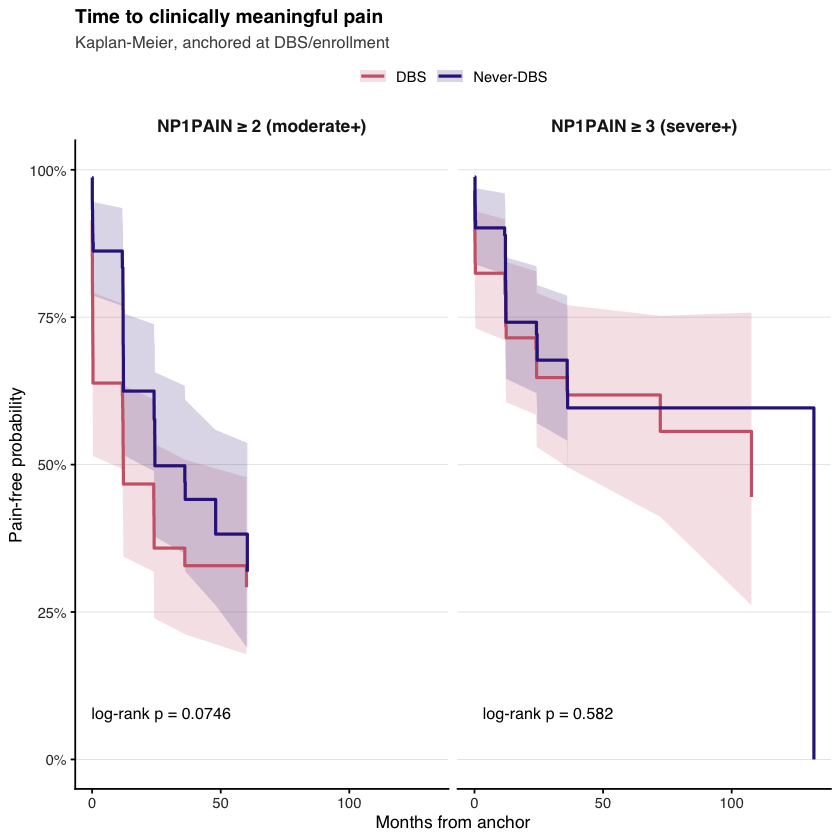

In [6]:
# ========= Figure 5 — Kaplan-Meier at two thresholds =========
ev3 <- readRDS(file.path(OUT_OBJ, "km_event_table.rds"))
ev2 <- readRDS(file.path(OUT_OBJ, "km_event_table_thr2.rds"))

pal <- c(`FALSE` = "#332288", `TRUE` = "#CC6677")

fit3 <- survival::survfit(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev3)
fit2 <- survival::survfit(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev2)
lr3 <- survival::survdiff(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev3)
lr2 <- survival::survdiff(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev2)
p3 <- signif(1 - pchisq(lr3$chisq, df = 1), 3)
p2 <- signif(1 - pchisq(lr2$chisq, df = 1), 3)

km_df <- function(fit, threshold) {
  s <- summary(fit)
  tibble::tibble(time = s$time, surv = s$surv, lo = s$lower, hi = s$upper,
                 strata = as.character(s$strata), threshold = threshold)
}
kmd <- dplyr::bind_rows(
  km_df(fit2, "NP1PAIN ≥ 2 (moderate+)"),
  km_df(fit3, "NP1PAIN ≥ 3 (severe+)")
) %>% dplyr::mutate(arm = dplyr::if_else(grepl("TRUE", strata), "DBS", "Never-DBS"))

lbls <- tibble::tibble(threshold = c("NP1PAIN ≥ 2 (moderate+)", "NP1PAIN ≥ 3 (severe+)"),
                       label = c(sprintf("log-rank p = %s", p2), sprintf("log-rank p = %s", p3)),
                       x = 54, y = 0.08)
fig5 <- ggplot(kmd, aes(time, surv, colour = arm, fill = arm)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.18, colour = NA) +
  geom_step(linewidth = 0.9) +
  facet_wrap(~ threshold, nrow = 1) +
  geom_text(data = lbls, aes(x = x, y = y, label = label), inherit.aes = FALSE, size = 3.4, hjust = 1) +
  scale_colour_manual(values = ARM_PAL, name = NULL) +
  scale_fill_manual(values = ARM_PAL, name = NULL) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0, 1)) +
  labs(title = "Time to clinically meaningful pain",
       subtitle = "Kaplan-Meier, anchored at DBS/enrollment",
       x = "Months from anchor", y = "Pain-free probability") +
  theme_pub()
fig5
save_pub(fig5, "Figure5_kaplan_meier", w = 11, h = 4.2)

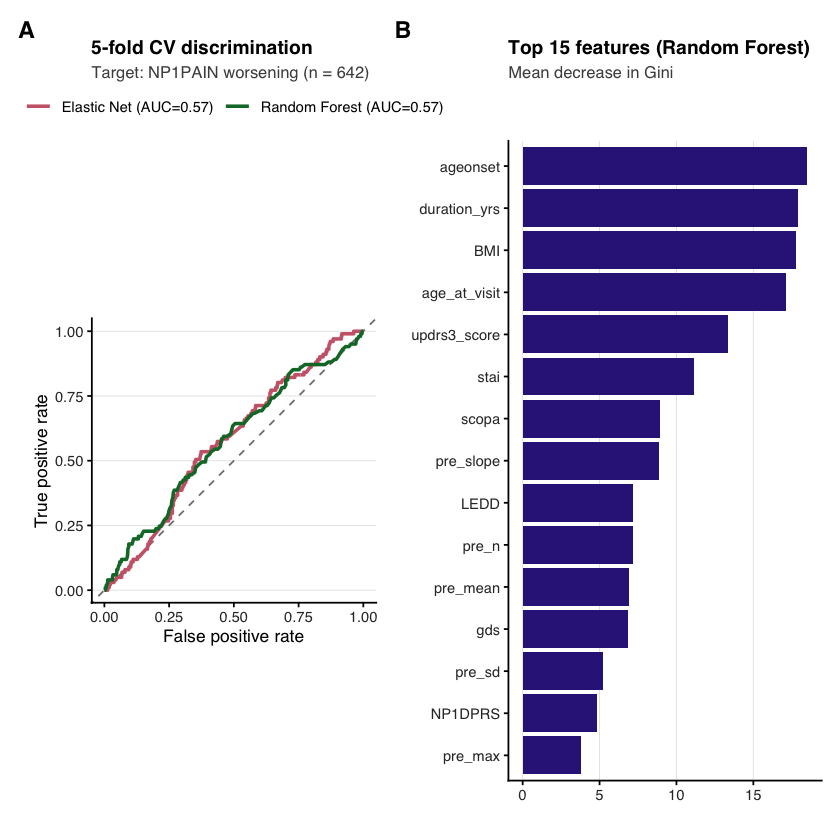

In [7]:
# ========= Figure 6 — Prediction model (ROC + importance) =========
imp <- readr::read_csv(file.path(OUT_TAB, "rf_importance_patient_anchor.csv"),
                       show_col_types = FALSE) %>%
  dplyr::arrange(dplyr::desc(MeanDecreaseGini)) %>% dplyr::slice_head(n = 15)

# Rebuild ROC quickly from saved object
dat <- readRDS(file.path(OUT_OBJ, "patient_anchor_features.rds"))
feature_cols <- c("dbs","age_at_visit","ageonset","duration_yrs","SEX","BMI",
                  "LEDD","updrs3_score","NHY","NP1DPRS","NP1ANXS","gds","stai","scopa",
                  "pre_mean","pre_max","pre_sd","pre_last","pre_slope","pre_n")
median_impute <- function(x){ x[is.na(x)] <- stats::median(x, na.rm=TRUE); x }
X <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(dplyr::all_of(feature_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute)) %>% as.matrix()
y <- dat$worsened

set.seed(42); folds <- sample(rep(1:5, length.out = nrow(X)))
suppressPackageStartupMessages({ library(randomForest); library(glmnet) })
p_rf <- numeric(nrow(X)); p_en <- numeric(nrow(X))
for (k in 1:5) {
  te <- which(folds == k); tr <- setdiff(seq_len(nrow(X)), te)
  set.seed(42)
  mrf <- randomForest::randomForest(x = X[tr,,drop=FALSE], y = factor(y[tr], levels = c(0,1)),
                                    ntree = 500, nodesize = 5)
  p_rf[te] <- as.numeric(predict(mrf, X[te,,drop=FALSE], type = "prob")[,"1"])
  set.seed(42)
  men <- glmnet::cv.glmnet(X[tr,,drop=FALSE], y[tr], family = "binomial", alpha = 0.5, nfolds = 5)
  p_en[te] <- as.numeric(predict(men, newx = X[te,,drop=FALSE], s = "lambda.min", type = "response"))
}
r_rf <- pROC::roc(y, p_rf, quiet = TRUE); auc_rf <- as.numeric(pROC::auc(r_rf))
r_en <- pROC::roc(y, p_en, quiet = TRUE); auc_en <- as.numeric(pROC::auc(r_en))
roc_df <- dplyr::bind_rows(
  tibble::tibble(model = sprintf("Random Forest (AUC=%.2f)", auc_rf), fpr = 1 - r_rf$specificities, tpr = r_rf$sensitivities),
  tibble::tibble(model = sprintf("Elastic Net (AUC=%.2f)", auc_en), fpr = 1 - r_en$specificities, tpr = r_en$sensitivities)
)

pA <- ggplot(roc_df, aes(fpr, tpr, colour = model)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
  geom_path(linewidth = 1) +
  scale_colour_manual(values = c("#CC6677","#117733"), name = NULL) +
  coord_equal() +
  labs(title = "5-fold CV discrimination",
       subtitle = sprintf("Target: NP1PAIN worsening (n = %d)", nrow(X)),
       x = "False positive rate", y = "True positive rate", tag = "A") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14))

pB <- ggplot(imp %>% dplyr::mutate(feature = forcats::fct_reorder(feature, MeanDecreaseGini)),
             aes(MeanDecreaseGini, feature)) +
  geom_col(fill = "#332288") +
  labs(title = "Top 15 features (Random Forest)",
       subtitle = "Mean decrease in Gini", x = NULL, y = NULL, tag = "B") +
  theme_pub() + theme(plot.tag = element_text(face = "bold", size = 14),
                      panel.grid.major.y = element_blank(),
                      panel.grid.major.x = element_line(colour = "grey90", linewidth = 0.25))

fig6 <- pA + pB + patchwork::plot_layout(ncol = 2, widths = c(1, 1.1))
fig6
save_pub(fig6, "Figure6_prediction", w = 11.5, h = 4.6)

Warning message:
“There were 3 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `x = dplyr::if_else(scale == "ratio", log(estimate), estimate)`.
Caused by warning in `log()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


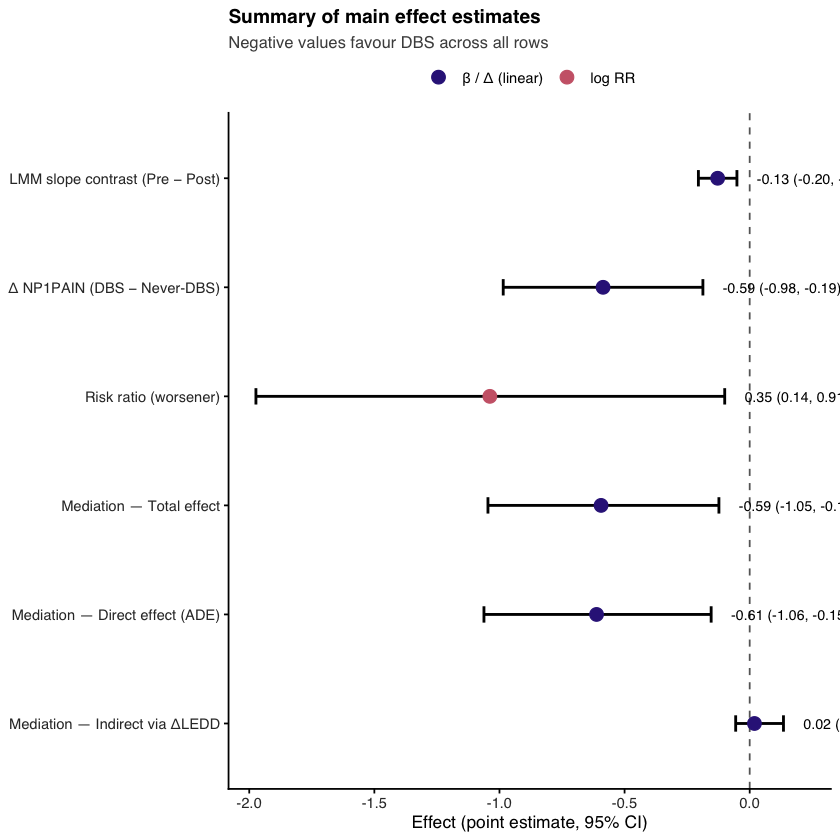

In [8]:
# ========= Figure 7 — Forest of main effect sizes across analyses =========
ev_rr <- readr::read_csv(file.path(OUT_TAB, "evalue_worsener_rr.csv"), show_col_types = FALSE)
# Build a compact summary table
items <- tibble::tribble(
  ~analysis,                             ~estimate, ~lci, ~uci, ~type,          ~scale,
  "LMM slope contrast (Pre − Post)",     -0.128,    -0.205, -0.051,  "β per year",  "linear",
  "Δ NP1PAIN (DBS − Never-DBS)",          -0.586,   -0.985, -0.187,  "points",      "linear",
  "Risk ratio (worsener)",                0.354,    0.139,  0.905,   "RR",          "ratio",
  "Mediation — Total effect",            -0.594,   -1.046, -0.123,  "points",      "linear",
  "Mediation — Direct effect (ADE)",     -0.612,   -1.062, -0.154,  "points",      "linear",
  "Mediation — Indirect via ΔLEDD",       0.019,   -0.056,  0.135,  "points",      "linear"
)
# For plotting on one axis: use signed magnitude for linear, log(RR) for ratio
items <- items %>% dplyr::mutate(
  x = dplyr::if_else(scale == "ratio", log(estimate), estimate),
  xlo = dplyr::if_else(scale == "ratio", log(lci), lci),
  xhi = dplyr::if_else(scale == "ratio", log(uci), uci),
  analysis = forcats::fct_rev(forcats::fct_inorder(analysis)),
  label = ifelse(scale == "ratio",
                 sprintf("%.2f (%.2f, %.2f)", estimate, lci, uci),
                 sprintf("%.2f (%.2f, %.2f)", estimate, lci, uci))
)
fig7 <- ggplot(items, aes(x = x, y = analysis)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = xlo, xmax = xhi), width = 0.15, orientation = "y", linewidth = 0.8) +
  geom_point(aes(colour = scale), size = 3.5) +
  geom_text(aes(x = xhi + 0.08, label = label), size = 3, hjust = 0) +
  scale_colour_manual(values = c("linear" = "#332288", "ratio" = "#CC6677"),
                      labels = c("linear" = "β / Δ (linear)", "ratio" = "log RR"),
                      name = NULL) +
  labs(title = "Summary of main effect estimates",
       subtitle = "Negative values favour DBS across all rows",
       x = "Effect (point estimate, 95% CI)", y = NULL) +
  coord_cartesian(clip = "off") +
  theme_pub() + theme(panel.grid.major.y = element_blank())
fig7
save_pub(fig7, "Figure7_forest_main_effects", w = 10.5, h = 4.2)

In [9]:
cat("=== Publication figures saved to Pain_paper_v2/outputs/figures/ ===\n")
cat("Figure1_trajectories.{png,tiff}\n")
cat("Figure2_waterfall_violin.{png,tiff}\n")
cat("Figure3_mediation.{png,tiff}\n")
cat("Figure4_network.{png,tiff}\n")
cat("Figure5_kaplan_meier.{png,tiff}\n")
cat("Figure6_prediction.{png,tiff}\n")
cat("Figure7_forest_main_effects.{png,tiff}\n")

=== Publication figures saved to Pain_paper_v2/outputs/figures/ ===


Figure1_trajectories.{png,tiff}


Figure2_waterfall_violin.{png,tiff}


Figure3_mediation.{png,tiff}


Figure4_network.{png,tiff}


Figure5_kaplan_meier.{png,tiff}


Figure6_prediction.{png,tiff}


Figure7_forest_main_effects.{png,tiff}
